In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import root_mean_squared_error
from sklearn.tree import export_text
from sklearn.ensemble import RandomForestRegressor

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

In [3]:
!wget $data

--2026-10-09 16:11:11--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.3’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.008s  

2026-10-09 16:11:12 (75.1 MB/s) - ‘car_fuel_efficiency_2026.csv.3’ saved [635180/635180]



In [4]:
df = pd.read_csv(data)
df.columns=df.columns.str.replace(' ','_').str.lower()

In [5]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [6]:
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

In [7]:
numerical = df.select_dtypes(include=['number']).columns
categorical = df.select_dtypes(exclude=['number']).columns

In [8]:
df[numerical] = df[numerical].fillna(0.0)
df[categorical] = df[categorical].fillna('NA')

In [9]:
df.isnull().sum()

model_year             0
origin                 0
fuel_type              0
drivetrain             0
num_doors              0
engine_displacement    0
num_cylinders          0
horsepower             0
vehicle_weight         0
acceleration           0
fuel_efficiency_mpg    0
dtype: int64

In [10]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=1
)

In [11]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [12]:
y_train=df_train.fuel_efficiency_mpg.values
y_val=df_val.fuel_efficiency_mpg.values
y_test=df_test.fuel_efficiency_mpg.values

In [13]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [14]:
train_dicts = df_train.to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

In [15]:
val_dicts = df_val.to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [16]:
dt = DecisionTreeRegressor(max_depth=1)
dt.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",1
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes m

In [17]:
tree_text = export_text(dt, feature_names=list(dv.get_feature_names_out()))
print(tree_text)

|--- model_year <= 1997.50
|   |--- value: [28.61]
|--- model_year >  1997.50
|   |--- value: [31.17]



In [18]:
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)
rmse = root_mean_squared_error(y_val, y_pred)
rmse

1.8336350509302553

In [19]:
ne_list = [10, 50, 100, 150]

for ne in ne_list:
  rf = RandomForestRegressor(n_estimators=ne, random_state=1, n_jobs=-1)
  rf.fit(X_train, y_train)

  y_pred = rf.predict(X_val)
  rmse = root_mean_squared_error(y_val, y_pred)

  print(f"n_estimators={ne} -> RMSE: {rmse:.3f}")

n_estimators=10 -> RMSE: 1.834
n_estimators=50 -> RMSE: 1.770
n_estimators=100 -> RMSE: 1.768
n_estimators=150 -> RMSE: 1.768


In [20]:
scores = []

for md in [10, 15, 20, 25]:
    for ne in [10, 50, 100, 150]:
        rf = RandomForestRegressor(
            max_depth=md, 
            n_estimators=ne, 
            random_state=1, 
            n_jobs=-1
        )
        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_val)
        rmse = root_mean_squared_error(y_val, y_pred)
        scores.append((md, ne, rmse))

df_scores = pd.DataFrame(scores, columns=['max_depth', 'n_estimators', 'rmse'])

best_idx = df_scores['rmse'].argmin()
best_row = df_scores.iloc[best_idx]

print("Best combination:")
print(f"max_depth = {int(best_row['max_depth'])}, n_estimators = {int(best_row['n_estimators'])}, RMSE = {best_row['rmse']:.4f}")

Best combination:
max_depth = 10, n_estimators = 150, RMSE = 1.7456


In [21]:
df_scores

,max_depth,n_estimators,rmse
0,10,10,1.785201
1,10,50,1.750440
2,10,100,1.746248
3,10,150,1.745575
4,15,10,1.833554
5,15,50,1.772616
6,15,100,1.766622
7,15,150,1.766335
8,20,10,1.830014
9,20,50,1.769503


In [23]:
        rf = RandomForestRegressor(
          n_estimators=10,
          max_depth=20,
          random_state=1,
          n_jobs=-1
        )
        rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_l

In [28]:
importances = rf.feature_importances_

In [ ]:
features = dv.get_feature_names_out()

In [40]:
df_importances = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values('importance', ascending=False)

print(df_importances)

                         feature  importance
9                     model_year    0.295822
15                vehicle_weight    0.203649
6             fuel_type=Gasoline    0.160713
8                     horsepower    0.078254
4            engine_displacement    0.061008
0                   acceleration    0.055466
14                    origin=USA    0.042232
5               fuel_type=Diesel    0.021128
2   drivetrain=Front-wheel drive    0.020005
11                     num_doors    0.019724
7               fuel_type=Hybrid    0.011685
1     drivetrain=All-wheel drive    0.007873
10                 num_cylinders    0.006939
12                   origin=Asia    0.006479
3    drivetrain=Rear-wheel drive    0.005636
13                 origin=Europe    0.003389


In [41]:
!pip install xgboost

In [42]:
import xgboost as xgb

In [ ]:
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [55]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [93]:
etas = [0.3, 0.1]
best_scores = {}

for eta in etas:
    xgb_params = {
        'eta': eta, 
        'max_depth': 6,
        'min_child_weight': 1,
        'objective': 'reg:squarederror',
        'nthread': 8,
        'seed': 1,
        'verbosity': 0,
    }
    
    evals_result = {}
    
    model = xgb.train(
        xgb_params, 
        dtrain, 
        num_boost_round=100, 
        evals=watchlist,
        evals_result=evals_result,
        verbose_eval=False
    )
    
    final_val_rmse = evals_result['val']['rmse'][-1]
    best_scores[eta] = final_val_rmse
    print(f"eta={eta} -> Final Validation RMSE: {final_val_rmse:.4f}")

best_eta = min(best_scores, key=best_scores.get)
print(f"\nBest eta is: {best_eta} with RMSE: {best_scores[best_eta]:.4f}")

eta=0.3 -> Final Validation RMSE: 1.8265
eta=0.1 -> Final Validation RMSE: 1.7248

Best eta is: 0.1 with RMSE: 1.7248


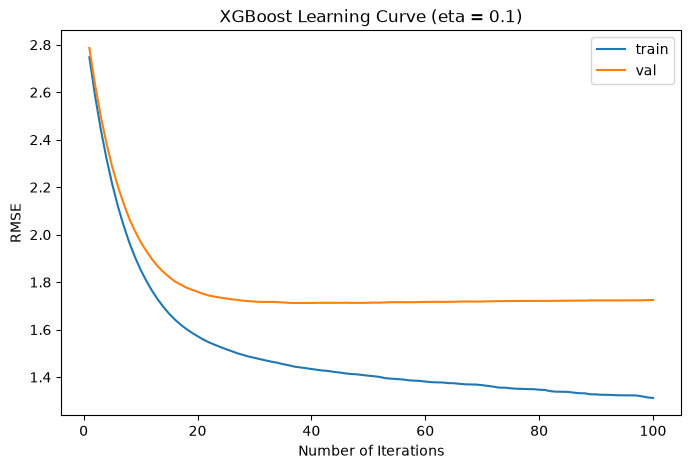

In [95]:
xgb_params = {
    'eta': 0.1,
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'reg:squarederror',
    'nthread': 8,
    'seed': 1,
    'verbosity': 0,
}

evals_result = {}

model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=100,
    evals=watchlist,
    evals_result=evals_result,
    verbose_eval=False,
)

df_score = pd.DataFrame(
    {
        'num_iter': range(1, len(evals_result['train']['rmse']) + 1),
        'train_rmse': evals_result['train']['rmse'],
        'val_rmse': evals_result['val']['rmse'],
    }
)

plt.figure(figsize=(8, 5))
plt.plot(df_score['num_iter'], df_score['train_rmse'], label='train')
plt.plot(df_score['num_iter'], df_score['val_rmse'], label='val')
plt.xlabel('Number of Iterations')
plt.ylabel('RMSE')
plt.title(f"XGBoost Learning Curve (eta = {xgb_params['eta']})")
plt.legend()
plt.show()